# Imports


In [220]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import TargetEncoder
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Loading the data


In [221]:
df = pd.read_csv("AmesHousing.csv")
print(df.head())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour Utilities Lot Config Land Slope Neighborhood  \
0   NaN       IR1          Lvl    AllPub     Corner        Gtl        NAmes   
1   NaN       Reg          Lvl    AllPub     Inside        Gtl        NAmes   
2   NaN       IR1          Lvl    AllPub     Corner        Gtl        NAmes   
3   NaN       Reg          Lvl    AllPub     Corner        Gtl        NAmes   
4   NaN       IR1          Lvl    AllPub     Inside        Gtl      Gilbert   

  Condition 1 Condition 2 Bldg Type House Style  Overall Qual 

In [222]:
target_col = "SalePrice"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

# Exploratory Data Analysis


Number of rows


In [223]:
print(n_rows := len(X_train))

2344


## Column stats


### Numeric columns


Distributions


In [224]:
pd.set_option("display.max_columns", None)
print(X_train.describe(include=[np.number]))

             Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2344.000000  2.344000e+03  2344.000000   1951.000000    2344.000000   
mean   1464.298635  7.143632e+08    57.308020     69.207586   10127.857509   
std     842.982263  1.886907e+08    42.802555     23.418018    8050.908132   
min       1.000000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     737.750000  5.284821e+08    20.000000     58.000000    7466.500000   
50%    1466.000000  5.354541e+08    50.000000     68.000000    9356.500000   
75%    2195.250000  9.071921e+08    70.000000     80.000000   11484.250000   
max    2930.000000  9.241520e+08   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count    2344.00000   2344.000000  2344.000000     2344.000000   2325.000000   
mean        6.06442      5.581911  1970.506826     1983.923635     98.539785   
std         1.38852      1.105659    30.341434       20.7

Missing values


In [225]:
print(
    (X_train.select_dtypes(include=[np.number]).isna().sum() / n_rows).sort_values(
        ascending=False
    )
)

Lot Frontage       0.167662
Garage Yr Blt      0.052048
Mas Vnr Area       0.008106
BsmtFin SF 2       0.000427
Bsmt Unf SF        0.000427
Total Bsmt SF      0.000427
Garage Cars        0.000427
Garage Area        0.000427
Bsmt Full Bath     0.000427
BsmtFin SF 1       0.000427
Bsmt Half Bath     0.000427
Order              0.000000
MS SubClass        0.000000
PID                0.000000
Overall Qual       0.000000
Lot Area           0.000000
Year Built         0.000000
2nd Flr SF         0.000000
Gr Liv Area        0.000000
Overall Cond       0.000000
1st Flr SF         0.000000
Year Remod/Add     0.000000
Half Bath          0.000000
Full Bath          0.000000
Low Qual Fin SF    0.000000
Bedroom AbvGr      0.000000
Fireplaces         0.000000
TotRms AbvGrd      0.000000
Kitchen AbvGr      0.000000
Wood Deck SF       0.000000
Open Porch SF      0.000000
Enclosed Porch     0.000000
3Ssn Porch         0.000000
Screen Porch       0.000000
Pool Area          0.000000
Misc Val           0

The maximum missing value percentage in a column is about 16%, which we should be able to deal with using data imputation.


### Categorical columns


Distributions


In [226]:
print(X_train.describe(include=["object", "category", "bool", "str"]))

       MS Zoning Street Alley Lot Shape Land Contour Utilities Lot Config  \
count       2344   2344   162      2344         2344      2344       2344   
unique         7      2     2         4            4         3          5   
top           RL   Pave  Grvl       Reg          Lvl    AllPub     Inside   
freq        1818   2333   100      1496         2109      2341       1716   

       Land Slope Neighborhood Condition 1 Condition 2 Bldg Type House Style  \
count        2344         2344        2344        2344      2344        2344   
unique          3           28           9           8         5           8   
top           Gtl        NAmes        Norm        Norm      1Fam      1Story   
freq         2228          367        2015        2324      1944        1191   

       Roof Style Roof Matl Exterior 1st Exterior 2nd Mas Vnr Type Exter Qual  \
count        2344      2344         2344         2344          918       2344   
unique          6         8           16           

Missing values


In [227]:
print(
    (X_train.select_dtypes(exclude=[np.number]).isna().sum() / n_rows).sort_values(
        ascending=False
    )
)

Pool QC           0.994881
Misc Feature      0.959898
Alley             0.930887
Fence             0.799488
Mas Vnr Type      0.608362
Fireplace Qu      0.488055
Garage Cond       0.052048
Garage Qual       0.052048
Garage Finish     0.052048
Garage Type       0.051195
Bsmt Exposure     0.026877
BsmtFin Type 2    0.026451
BsmtFin Type 1    0.026024
Bsmt Qual         0.026024
Bsmt Cond         0.026024
Condition 2       0.000000
Condition 1       0.000000
Land Contour      0.000000
Lot Shape         0.000000
Street            0.000000
MS Zoning         0.000000
Neighborhood      0.000000
Land Slope        0.000000
Lot Config        0.000000
Utilities         0.000000
Roof Style        0.000000
Bldg Type         0.000000
Heating           0.000000
Exter Cond        0.000000
Foundation        0.000000
House Style       0.000000
Roof Matl         0.000000
Exterior 1st      0.000000
Exterior 2nd      0.000000
Exter Qual        0.000000
Functional        0.000000
Central Air       0.000000
E

Some columns are missing over 90% of values, which can be problematic - data imputation probably isn't a good idea in those cases.


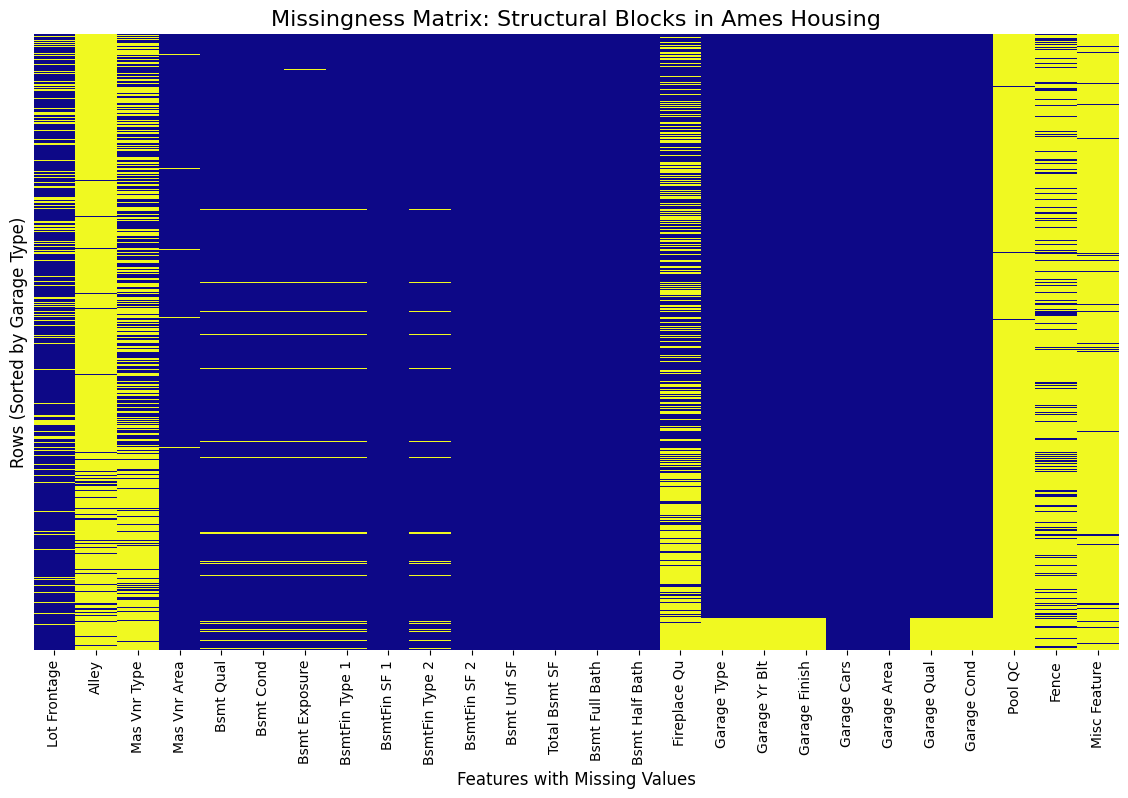

In [228]:
cols_with_missing = X_train.columns[X_train.isnull().any()].tolist()
X_missing = X_train[cols_with_missing]

X_missing_sorted = X_missing.sort_values(by="Garage Type", na_position="last")

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    X_missing_sorted.isnull(), cbar=False, cmap="plasma", yticklabels=False, ax=ax
)

ax.set_title("Missingness Matrix: Structural Blocks in Ames Housing", fontsize=16)
ax.set_xlabel("Features with Missing Values", fontsize=12)
ax.set_ylabel("Rows (Sorted by Garage Type)", fontsize=12)

plt.show()


There are groups of columns whose values are missing for the same rows - for example, the garage-related columns, probably indicating that these house don't have a garage.


### Target column


Distribution


In [229]:
print(y_train.describe())

count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Missing values


In [230]:
print(y_train.isna().sum() / n_rows)

0.0


## Distributions and correlations


### Mutual information


In [231]:
X_mi = X_train.copy().loc[
    :,
    ~X_train.columns.isin(
        [
            "Id",
            "PID",
            "Order",
            "Pool QC",
            "Misc Feature",
            "Alley",
            "Fence",
            "Mas Vnr Type",
            "Fireplace Qu",
        ]
    ),
]
y_mi = y_train.copy()

valid_indices = X_mi.dropna().index
X_mi = X_mi.loc[valid_indices]
y_mi = y_mi.loc[valid_indices]

for colname in X_mi.select_dtypes("object"):
    X_mi[colname], _ = X_mi[colname].factorize()


discrete_features = np.array([np.issubdtype(t, np.integer) for t in X_mi.dtypes])

mi_scores = mutual_info_regression(
    X_mi, y_mi, discrete_features=discrete_features, random_state=42
)

mi_results = pd.Series(mi_scores, name="MI Scores", index=X_mi.columns)
pd.set_option("display.max_rows", None)
print(mi_results.sort_values(ascending=False))

C:\Users\Kacper\AppData\Local\Temp\ipykernel_15748\3571825990.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X_mi.select_dtypes("object"):


Overall Qual       5.817375e-01
Neighborhood       5.598595e-01
Lot Area           5.088055e-01
Year Built         4.726177e-01
Gr Liv Area        4.255235e-01
1st Flr SF         3.809386e-01
Garage Area        3.781896e-01
Bsmt Qual          3.773370e-01
Total Bsmt SF      3.676227e-01
Garage Cars        3.570050e-01
Exter Qual         3.130843e-01
Year Remod/Add     3.124184e-01
Kitchen Qual       3.110023e-01
Full Bath          3.029073e-01
MS SubClass        2.928010e-01
Garage Yr Blt      2.876642e-01
Lot Frontage       2.299911e-01
Foundation         2.258406e-01
Garage Finish      2.244459e-01
TotRms AbvGrd      2.037666e-01
BsmtFin SF 1       2.008500e-01
Open Porch SF      1.899614e-01
Garage Type        1.817262e-01
Heating QC         1.725460e-01
BsmtFin Type 1     1.643141e-01
Exterior 2nd       1.614672e-01
Mas Vnr Area       1.610110e-01
2nd Flr SF         1.515073e-01
Fireplaces         1.475267e-01
Exterior 1st       1.445602e-01
Overall Cond       1.314261e-01
MS Zonin

### Histograms


Features


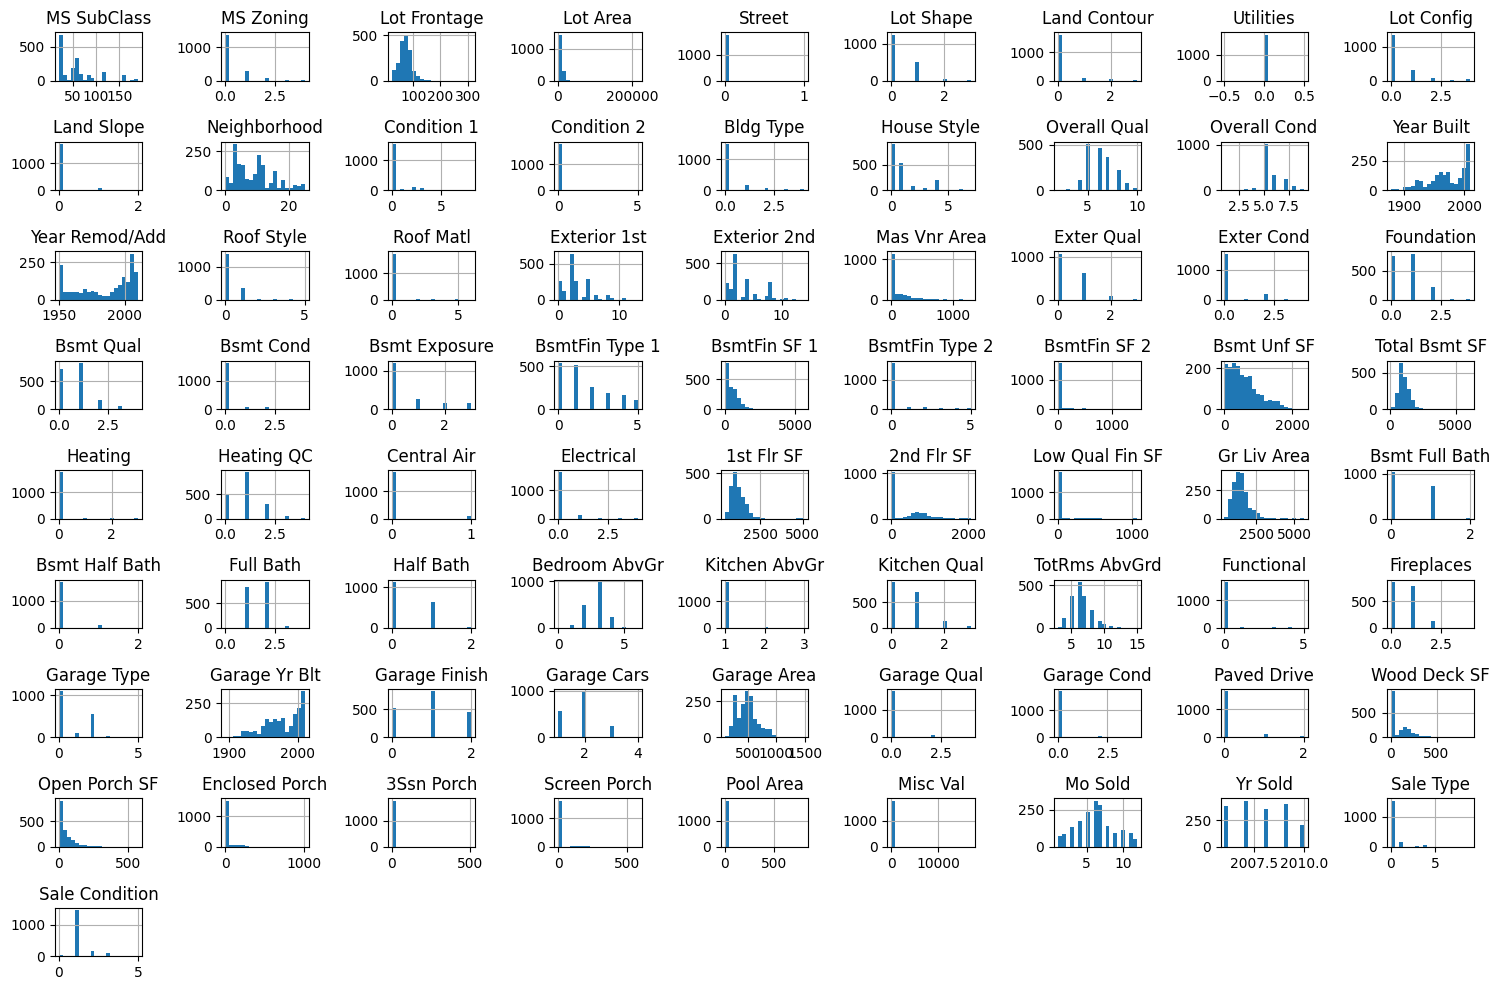

In [232]:
X_mi.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()


Target


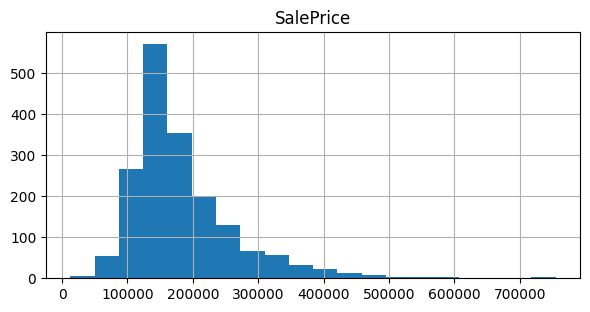

In [233]:
y_mi.hist(bins=20, figsize=(6, 3))
plt.tight_layout()
plt.title("SalePrice")
plt.show()


The target variable shows a large skew towards the right, which can negatively impact predictions results, overestimating the target value for the majority of samples.


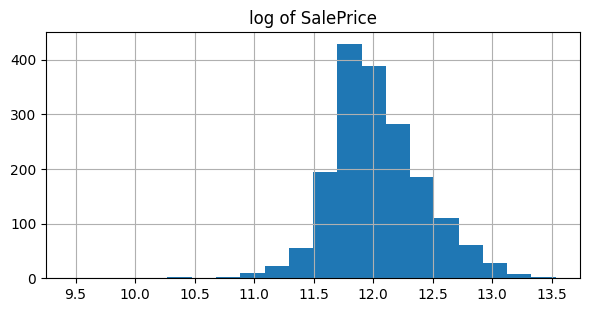

In [234]:
np.log1p(y_mi).hist(bins=20, figsize=(6, 3))
plt.tight_layout()
plt.title("log of SalePrice")
plt.show()


### Feature correlations


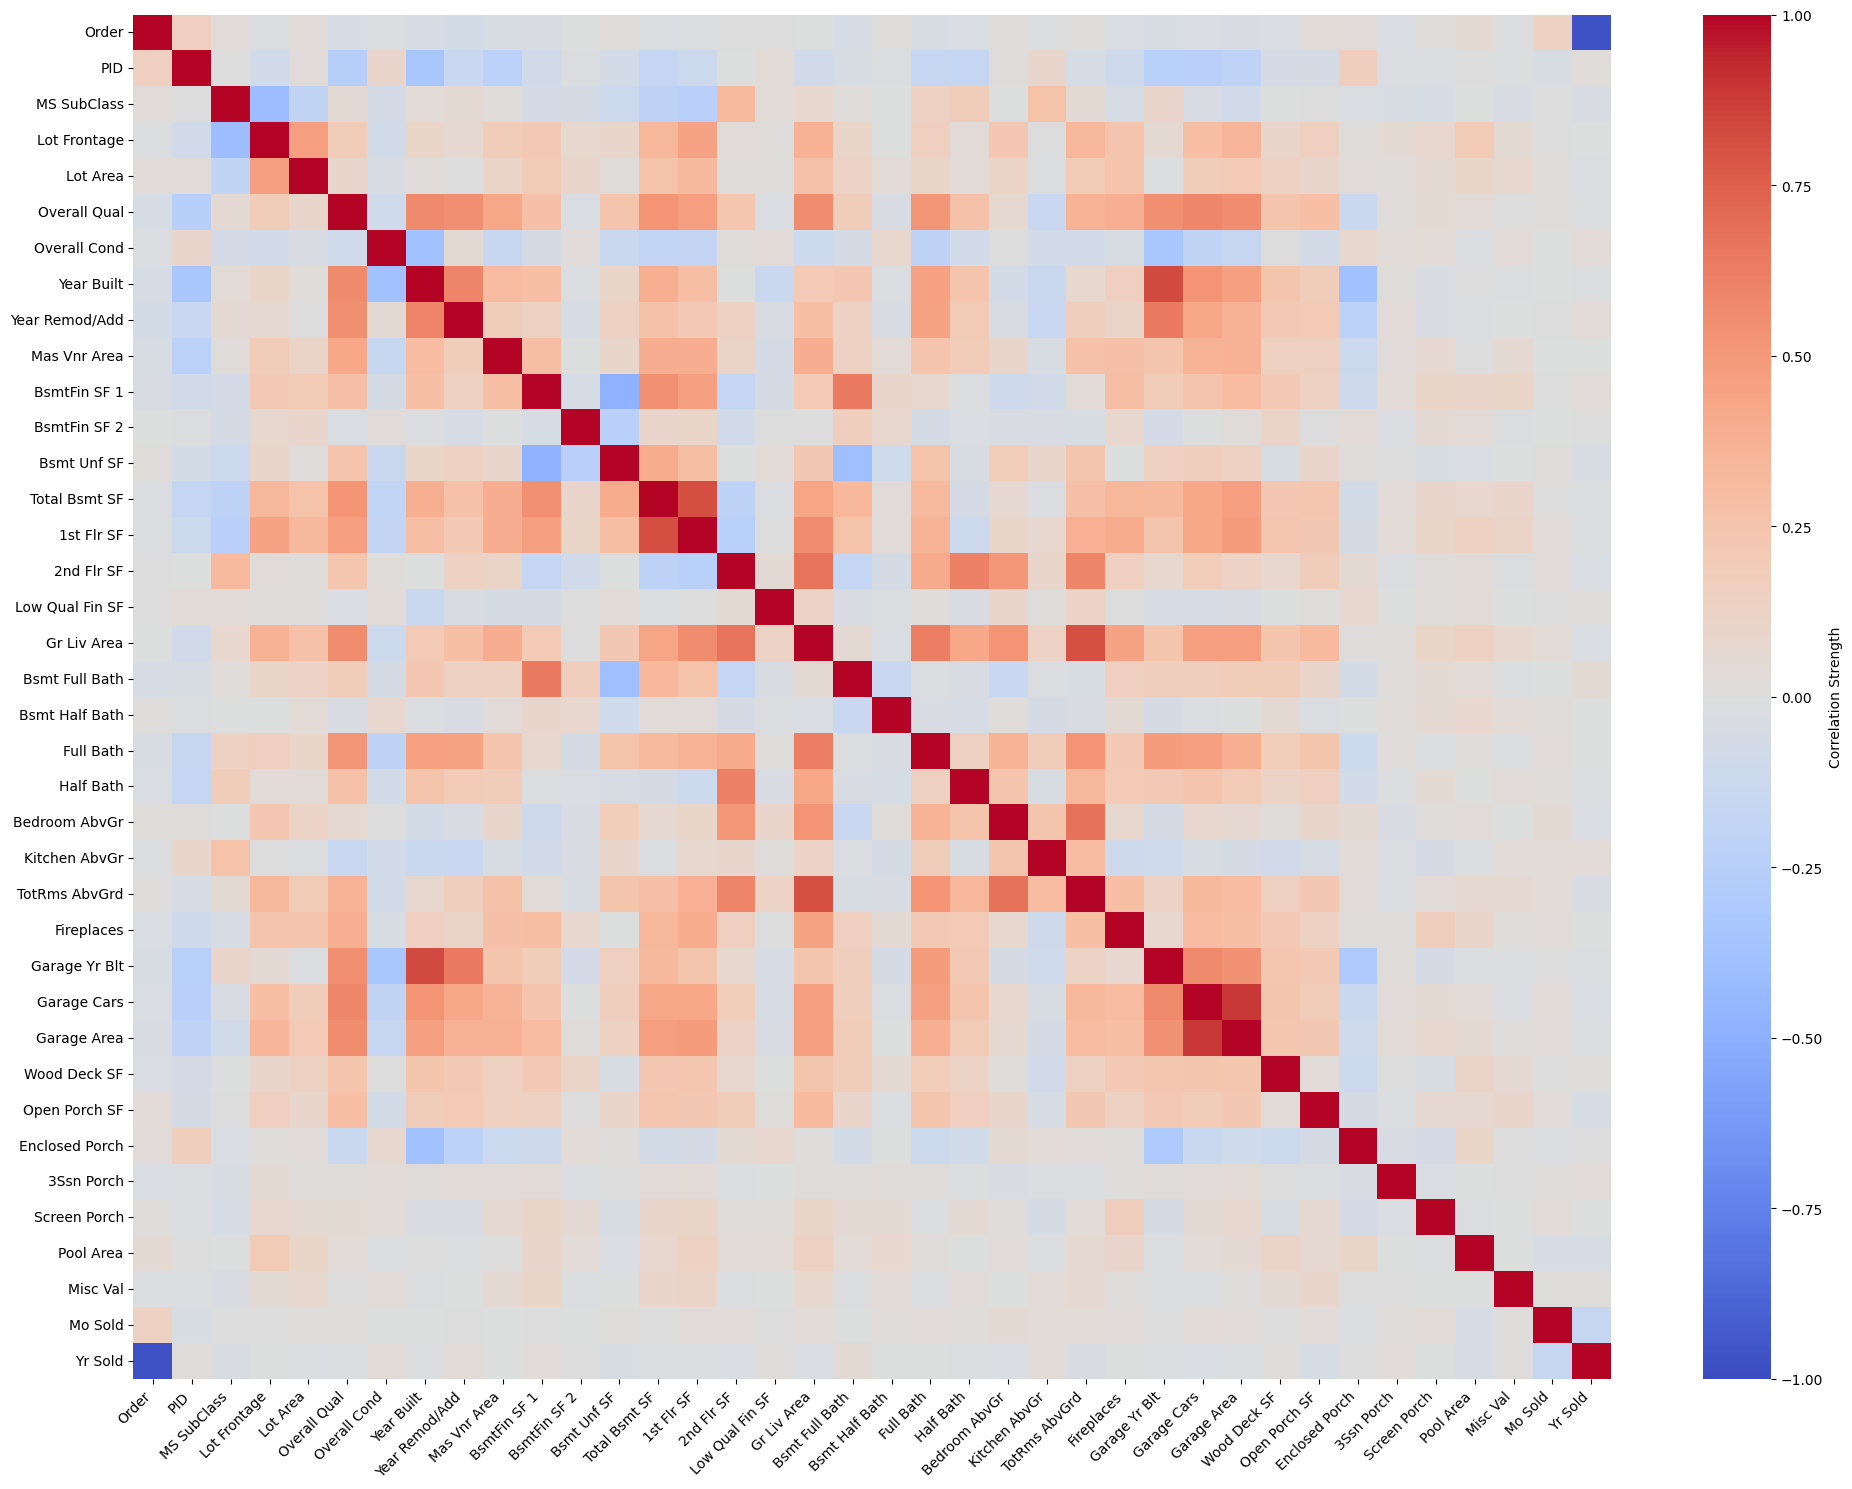

In [235]:
plt.figure(figsize=(20, 15))

corr = X_train.corr(numeric_only=True)

ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar=True,
    xticklabels=corr.columns,
    yticklabels=corr.columns,
    annot=False,
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

cbar = ax.collections[0].colorbar
cbar.set_label("Correlation Strength")

plt.tight_layout()
plt.show()


# Models


Remove ID columns


In [236]:
X_train = X_train.loc[:, ~X_train.columns.isin(["Id", "PID", "Order"])]

## Random Forest


### First try - naive approach, no tuning, basic data preprocessing


In [237]:
rf_X_train, rf_X_val, rf_y_train, rf_y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                    ),
                ]
            ),
            cat_cols,
        ),
    ]
)

rf_simple = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)

rf_simple.fit(rf_X_train, rf_y_train)

preds = rf_simple.predict(rf_X_val)

print(f"Val MAE: {mean_absolute_error(rf_y_val, preds):.2f}")


C:\Users\Kacper\AppData\Local\Temp\ipykernel_15748\3886491489.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


Val MAE: 15940.36


### GridSearch function


In [238]:
def fit_hyperparameters(model, parameters, X, y, n_iter):
    gs = RandomizedSearchCV(model, parameters, n_iter=n_iter, n_jobs=-1)
    gs.fit(X, y)
    return gs.best_estimator_, gs.best_params_


### Random Forest with tuned hyperparameters


In [239]:
rf_X_train, rf_X_val, rf_y_train, rf_y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                    ),
                ]
            ),
            cat_cols,
        ),
    ]
)

rf_pipeline = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor()),
    ]
)

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__bootstrap": [True, False],
}
rF_tuned, best_params = fit_hyperparameters(
    rf_pipeline, param_grid, rf_X_train, rf_y_train, 50
)

preds = rF_tuned.predict(rf_X_val)

print(f"Best params: {best_params}")
print(f"Val MAE: {mean_absolute_error(rf_y_val, preds):.2f}")


C:\Users\Kacper\AppData\Local\Temp\ipykernel_15748\2448469870.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


Best params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30, 'model__bootstrap': False}
Val MAE: 15019.34


Tuning the hyperparameters has lead to a slight improvement.


### Random Forest with tuned hyperparameters + log scaling the target


In [240]:
rf_X_train, rf_X_val, rf_y_train, rf_y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                    ),
                ]
            ),
            cat_cols,
        ),
    ]
)

rf_pipeline = Pipeline(
    [
        ("preprocessor", tree_preprocessor),
        (
            "model",
            TransformedTargetRegressor(
                regressor=RandomForestRegressor(), func=np.log1p, inverse_func=np.expm1
            ),
        ),
    ]
)

param_grid = {
    "model__regressor__n_estimators": [100, 200, 300, 500],
    "model__regressor__max_depth": [None, 5, 10, 15, 20, 30],
    "model__regressor__min_samples_split": [2, 5, 10, 20],
    "model__regressor__min_samples_leaf": [1, 2, 4, 8],
    "model__regressor__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__regressor__bootstrap": [True, False],
}
rf_log, best_params = fit_hyperparameters(
    rf_pipeline, param_grid, rf_X_train, rf_y_train, 50
)

preds = rf_log.predict(rf_X_val)

print(f"Best params: {best_params}")
print(f"Val MAE: {mean_absolute_error(rf_y_val, preds):.2f}")


C:\Users\Kacper\AppData\Local\Temp\ipykernel_15748\3399651666.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


Best params: {'model__regressor__n_estimators': 200, 'model__regressor__min_samples_split': 2, 'model__regressor__min_samples_leaf': 1, 'model__regressor__max_features': 0.3, 'model__regressor__max_depth': None, 'model__regressor__bootstrap': False}
Val MAE: 15003.38


Log transformation of the target value has improved the results slightly.


## XGBoost


### Standard


In [241]:
xgb_base = XGBRegressor(tree_method="hist", random_state=42, n_jobs=-1)

xgb_target_model = TransformedTargetRegressor(
    regressor=xgb_base, func=np.log1p, inverse_func=np.expm1
)

xgb_pipeline = Pipeline(
    [("preprocessor", tree_preprocessor), ("model", xgb_target_model)]
)

param_distributions = {
    "model__regressor__n_estimators": [500, 1000, 2000],
    "model__regressor__learning_rate": [0.01, 0.05, 0.1],
    "model__regressor__max_depth": [3, 5, 6, 8],
    "model__regressor__subsample": [0.6, 0.8, 1.0],
    "model__regressor__colsample_bytree": [0.4, 0.6, 0.8],
    "model__regressor__reg_alpha": [0, 0.1, 1, 10],
    "model__regressor__reg_lambda": [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

xgb_search.fit(rf_X_train, rf_y_train)

xgb_simple = xgb_search.best_estimator_
preds = xgb_simple.predict(rf_X_val)
print(f"XGBoost Val MAE: {mean_absolute_error(rf_y_val, preds):.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost Val MAE: 14450.59


### With data preprocessing


In [242]:
def engineer_features(X):
    X = X.copy()
    # Total usable square footage (Basement + Above Ground)
    X["TotalSF"] = X["Total Bsmt SF"] + X["Gr Liv Area"]
    # Total number of bathrooms
    X["TotalBath"] = (
        X["Full Bath"]
        + (0.5 * X["Half Bath"])
        + X["Bsmt Full Bath"]
        + (0.5 * X["Bsmt Half Bath"])
    )
    # Age of the house at the time of sale
    X["HouseAge"] = X["Yr Sold"] - X["Year Built"]
    # Years since last significant remodel
    X["YearsSinceRemodel"] = X["Yr Sold"] - X["Year Remod/Add"]
    return X


feature_eng_transformer = FunctionTransformer(engineer_features)

engineered_cols = ["TotalSF", "TotalBath", "HouseAge", "YearsSinceRemodel"]

num_cols_zero = [
    "Garage Area",
    "Garage Cars",
    "Total Bsmt SF",
    "BsmtFin SF 1",
    "Mas Vnr Area",
    "Bsmt Unf SF",
]
num_cols_median = [c for c in num_cols if c not in num_cols_zero] + engineered_cols

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), num_cols_zero),
        (
            "num_median",
            SimpleImputer(strategy="median", add_indicator=True),
            num_cols_median,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                    ),
                ]
            ),
            cat_cols,
        ),
    ]
)

xgb_pipeline = Pipeline(
    [
        ("feature_eng", feature_eng_transformer),
        ("preprocessor", tree_preprocessor),
        ("model", xgb_target_model),
    ]
)


xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

xgb_search.fit(rf_X_train, rf_y_train)
best_xgb = xgb_search.best_estimator_
preds = best_xgb.predict(rf_X_val)

print(f"Improved XGBoost Val MAE: {mean_absolute_error(rf_y_val, preds):.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Improved XGBoost Val MAE: 13216.65


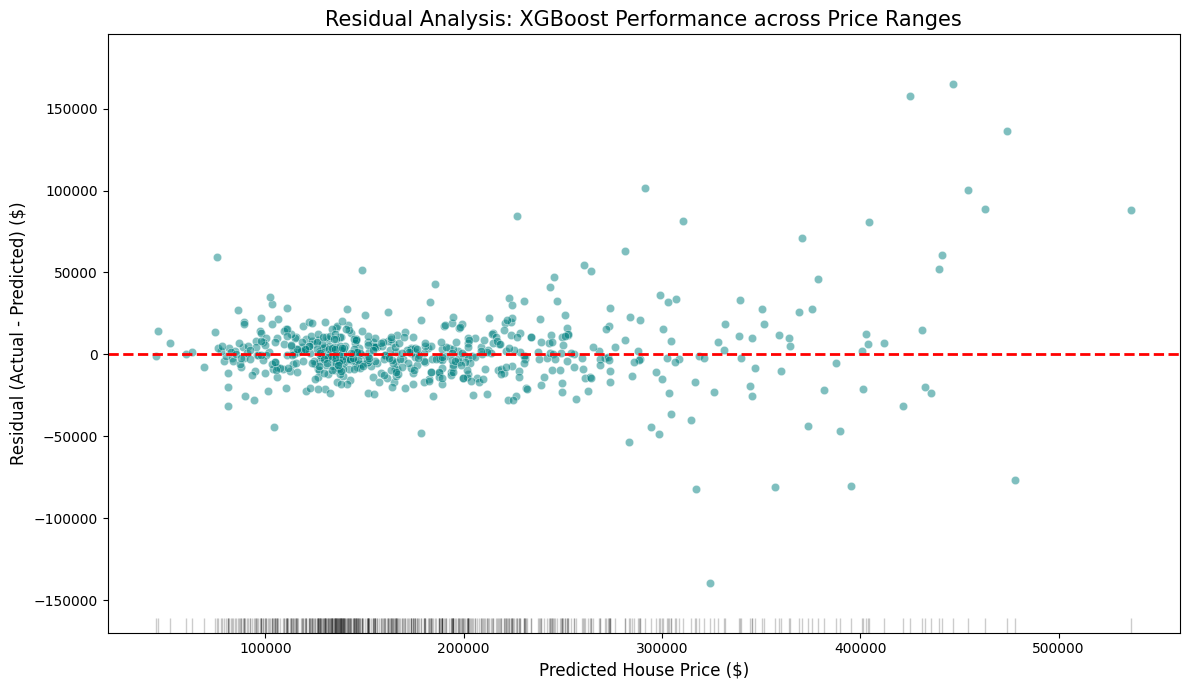

In [243]:
y_val_preds = best_xgb.predict(rf_X_val)
residuals = rf_y_val - y_val_preds

plt.figure(figsize=(12, 7))

sns.scatterplot(x=y_val_preds, y=residuals, alpha=0.5, color="teal")

plt.axhline(y=0, color="red", linestyle="--", linewidth=2)

plt.title("Residual Analysis: XGBoost Performance across Price Ranges", fontsize=15)
plt.xlabel("Predicted House Price ($)", fontsize=12)
plt.ylabel("Residual (Actual - Predicted) ($)", fontsize=12)

sns.rugplot(x=y_val_preds, color="black", alpha=0.2)

plt.tight_layout()
plt.show()


Improvements made:

- Engineered features:
  - total usable square footage
  - total number of bathrooms
  - age of the house at the time of sale
  - years between last remodel and sale
- Replaced median NaN imputation with zeros for columns related to garages and basements, as it makes more sense to indicate that a house doesn't have those
- Added early stopping to XGBoost


The model's performance is increasingly poor for more expensive houses.


### XGBoost final


In [244]:
def engineer_features(X):
    X = X.copy()
    # Total usable square footage (Basement + Above Ground)
    X["TotalSF"] = X["Total Bsmt SF"] + X["Gr Liv Area"]
    # Total number of bathrooms
    X["TotalBath"] = (
        X["Full Bath"]
        + (0.5 * X["Half Bath"])
        + X["Bsmt Full Bath"]
        + (0.5 * X["Bsmt Half Bath"])
    )
    # Age of the house at the time of sale
    X["HouseAge"] = X["Yr Sold"] - X["Year Built"]
    # Years since last significant remodel
    X["YearsSinceRemodel"] = X["Yr Sold"] - X["Year Remod/Add"]
    return X


feature_eng_transformer = FunctionTransformer(engineer_features)
cat_cols_new = cat_cols.copy()
cat_cols_new.remove("Neighborhood")

num_cols_zero = [
    "Garage Area",
    "Garage Cars",
    "Total Bsmt SF",
    "BsmtFin SF 1",
    "Mas Vnr Area",
    "Bsmt Unf SF",
]

engineered_cols = ["TotalSF", "TotalBath", "HouseAge", "YearsSinceRemodel"]
num_cols_median = [c for c in num_cols if c not in num_cols_zero] + engineered_cols

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), num_cols_zero),
        (
            "num_median",
            SimpleImputer(strategy="median", add_indicator=True),
            num_cols_median,
        ),
        (
            "neighborhood_price",
            TargetEncoder(target_type="continuous"),
            ["Neighborhood"],
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                    ),
                ]
            ),
            cat_cols_new,
        ),
    ]
)

xgb_pipeline = Pipeline(
    [
        ("feature_eng", feature_eng_transformer),
        ("preprocessor", tree_preprocessor),
        ("model", xgb_target_model),
    ]
)


xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

threshold = rf_y_train.quantile(0.5)
weights = np.where(rf_y_train > threshold, 2.5, 1.0)

xgb_search.fit(rf_X_train, rf_y_train, model__sample_weight=weights)
xgb_final = xgb_search.best_estimator_
preds = xgb_final.predict(rf_X_val)

print(f"Improved XGBoost Val MAE: {mean_absolute_error(rf_y_val, preds):.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Improved XGBoost Val MAE: 13837.26


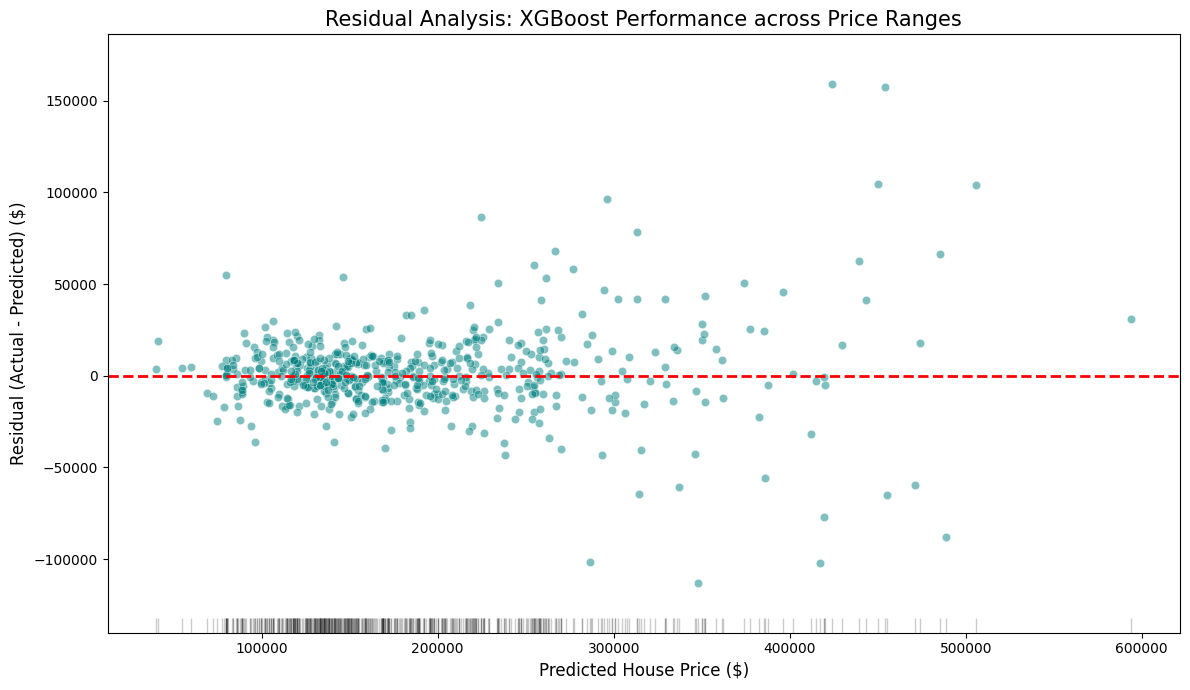

In [245]:
y_val_preds = xgb_final.predict(rf_X_val)
residuals = rf_y_val - y_val_preds

plt.figure(figsize=(12, 7))

sns.scatterplot(x=y_val_preds, y=residuals, alpha=0.5, color="teal")

plt.axhline(y=0, color="red", linestyle="--", linewidth=2)

plt.title("Residual Analysis: XGBoost Performance across Price Ranges", fontsize=15)
plt.xlabel("Predicted House Price ($)", fontsize=12)
plt.ylabel("Residual (Actual - Predicted) ($)", fontsize=12)

sns.rugplot(x=y_val_preds, color="black", alpha=0.2)

plt.tight_layout()
plt.show()


Two changes were made to try achieving better predictions for expensive houses:

- target encoding the 'Neighborhood' column
- tuning the weight of the more expensive houses to be 2.5 in the loss function

Both methods failed to improve predictions for higher prices, suggesting that the information ceiling has been hit.


## Simple Neural Network


In [246]:
def engineer_features(X):
    X = X.copy()
    X["TotalSF"] = X["Total Bsmt SF"] + X["Gr Liv Area"]
    X["TotalBath"] = (
        X["Full Bath"]
        + (0.5 * X["Half Bath"])
        + X["Bsmt Full Bath"]
        + (0.5 * X["Bsmt Half Bath"])
    )
    X["HouseAge"] = X["Yr Sold"] - X["Year Built"]
    X["YearsSinceRemodel"] = X["Yr Sold"] - X["Year Remod/Add"]
    return X


feature_eng_transformer = FunctionTransformer(engineer_features)

engineered_cols = ["TotalSF", "TotalBath", "HouseAge", "YearsSinceRemodel"]

num_cols_zero = [
    "Garage Area",
    "Garage Cars",
    "Total Bsmt SF",
    "BsmtFin SF 1",
    "Mas Vnr Area",
    "Bsmt Unf SF",
]

num_cols_median = [c for c in num_cols if c not in num_cols_zero] + engineered_cols

nn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num_zero",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols_zero,
        ),
        (
            "num_median",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols_median,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    (
                        "ohe",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            cat_cols_new,
        ),
    ]
)

full_nn_preprocessor = Pipeline(
    [("feature_eng", feature_eng_transformer), ("preprocessor", nn_preprocessor)]
)

X_train_nn = full_nn_preprocessor.fit_transform(rf_X_train)
X_val_nn = full_nn_preprocessor.transform(rf_X_val)

y_train_nn = np.log1p(rf_y_train)
y_val_nn = np.log1p(rf_y_val)

simple_nn = Sequential(
    [
        Dense(256, activation="relu", input_shape=(X_train_nn.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.1),
        Dense(1),
    ]
)

simple_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")

early_stopping = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = simple_nn.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

nn_preds_log = simple_nn.predict(X_val_nn).flatten()
nn_preds = np.expm1(nn_preds_log)

print(f"Neural Network Val RMSE: {root_mean_squared_error(rf_y_val, nn_preds):.2f}")
print(f"Neural Network Val MAE: {mean_absolute_error(rf_y_val, nn_preds):.2f}")


Epoch 1/300


d:\Users\Kacper\Desktop\ml-experiments\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 136.3916 - val_loss: 124.6259
Epoch 2/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.9550 - val_loss: 91.3580
Epoch 3/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 67.3911 - val_loss: 48.0185
Epoch 4/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28.6768 - val_loss: 14.1760
Epoch 5/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.6035 - val_loss: 3.1114
Epoch 6/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.8869 - val_loss: 0.7115
Epoch 7/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6993 - val_loss: 0.5822
Epoch 8/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3011 - val_loss: 1.0148
Epoch 9/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0826 - val_loss: 0.7174
Epoch 10/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8917 - val_loss: 0.3990
Epoch 11/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6168 - val_loss: 0.3837
Epoch 12/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.69

## Residual Neural Network


In [247]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

inputs = Input(shape=(X_train_nn.shape[1],))

x = Dense(128, activation="relu")(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

res1 = Dense(128, activation="relu")(x)
res1 = BatchNormalization()(res1)
res1 = Dropout(0.2)(res1)
x = Add()([x, res1])

res2 = Dense(128, activation="relu")(x)
res2 = BatchNormalization()(res2)
res2 = Dropout(0.2)(res2)
x = Add()([x, res2])

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

outputs = Dense(1)(x)

res_nn = Model(inputs=inputs, outputs=outputs)

res_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="mse")

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=0.0001)

early_stopping = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = res_nn.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

nn_preds_log = res_nn.predict(X_val_nn).flatten()
nn_preds = np.expm1(nn_preds_log)

print(f"Residual NN Val RMSE: {root_mean_squared_error(rf_y_val, nn_preds):.2f}")
print(f"Residual NN Val MAE: {mean_absolute_error(rf_y_val, nn_preds):.2f}")


Epoch 1/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 74.6897 - val_loss: 5.1368 - learning_rate: 0.0050
Epoch 2/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8013 - val_loss: 0.7089 - learning_rate: 0.0050
Epoch 3/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6557 - val_loss: 0.7686 - learning_rate: 0.0050
Epoch 4/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2953 - val_loss: 0.4369 - learning_rate: 0.0050
Epoch 5/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1001 - val_loss: 0.1151 - learning_rate: 0.0050
Epoch 6/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9913 - val_loss: 0.2371 - learning_rate: 0.0050
Epoch 7/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8879 - val_loss: 0.0765 - learning_rate: 0.0050
Epoch 8/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8409 - val_loss: 0.0391 - learning_rate: 0.0050
Epoch 9/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7231 - val_loss: 0.0955 - learning_rate: 0.0050
Epoch 10/300
74/74

## Wide & Deep Neural Network


In [248]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

inputs = Input(shape=(X_train_nn.shape[1],))

deep = Dense(256, activation="relu")(inputs)
deep = BatchNormalization()(deep)
deep = Dropout(0.3)(deep)

deep = Dense(128, activation="relu")(deep)
deep = BatchNormalization()(deep)
deep = Dropout(0.2)(deep)

deep = Dense(64, activation="relu")(deep)
deep = BatchNormalization()(deep)
deep = Dropout(0.1)(deep)

wide_and_deep = Concatenate()([inputs, deep])

outputs = Dense(1)(wide_and_deep)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002), loss="mse")

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=0.0001)

early_stopping = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

nn_preds_log = model.predict(X_val_nn).flatten()
nn_preds = np.expm1(nn_preds_log)

print(f"Wide & Deep NN Val RMSE: {root_mean_squared_error(rf_y_val, nn_preds):.2f}")
print(f"Wide & Deep NN Val MAE: {mean_absolute_error(rf_y_val, nn_preds):.2f}")


Epoch 1/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 76.5277 - val_loss: 26.0007 - learning_rate: 0.0020
Epoch 2/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.7017 - val_loss: 0.2911 - learning_rate: 0.0020
Epoch 3/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9069 - val_loss: 0.4444 - learning_rate: 0.0020
Epoch 4/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6634 - val_loss: 0.6808 - learning_rate: 0.0020
Epoch 5/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5060 - val_loss: 0.3107 - learning_rate: 0.0020
Epoch 6/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4352 - val_loss: 0.4107 - learning_rate: 0.0020
Epoch 7/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4007 - val_loss: 0.1830 - learning_rate: 0.0020
Epoch 8/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3403 - val_loss: 0.1561 - learning_rate: 0.0020
Epoch 9/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2898 - val_loss: 0.2511 - learning_rate: 0.0020
Epoch 10/300
74/7

# Test set evaluation


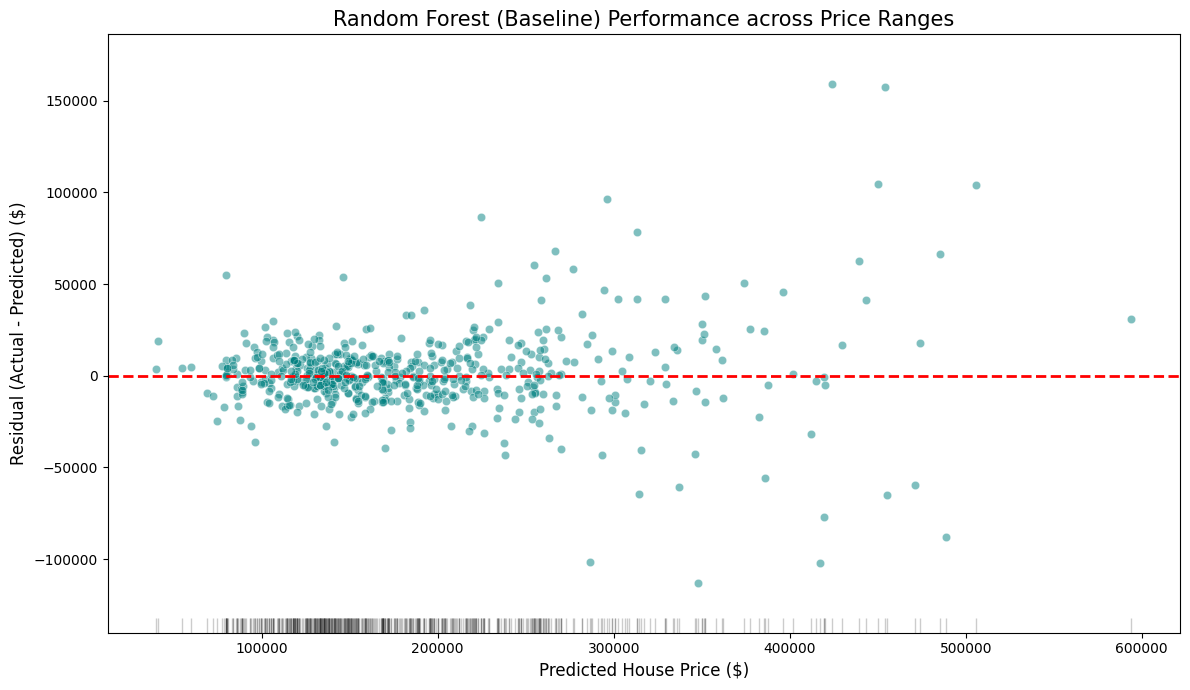

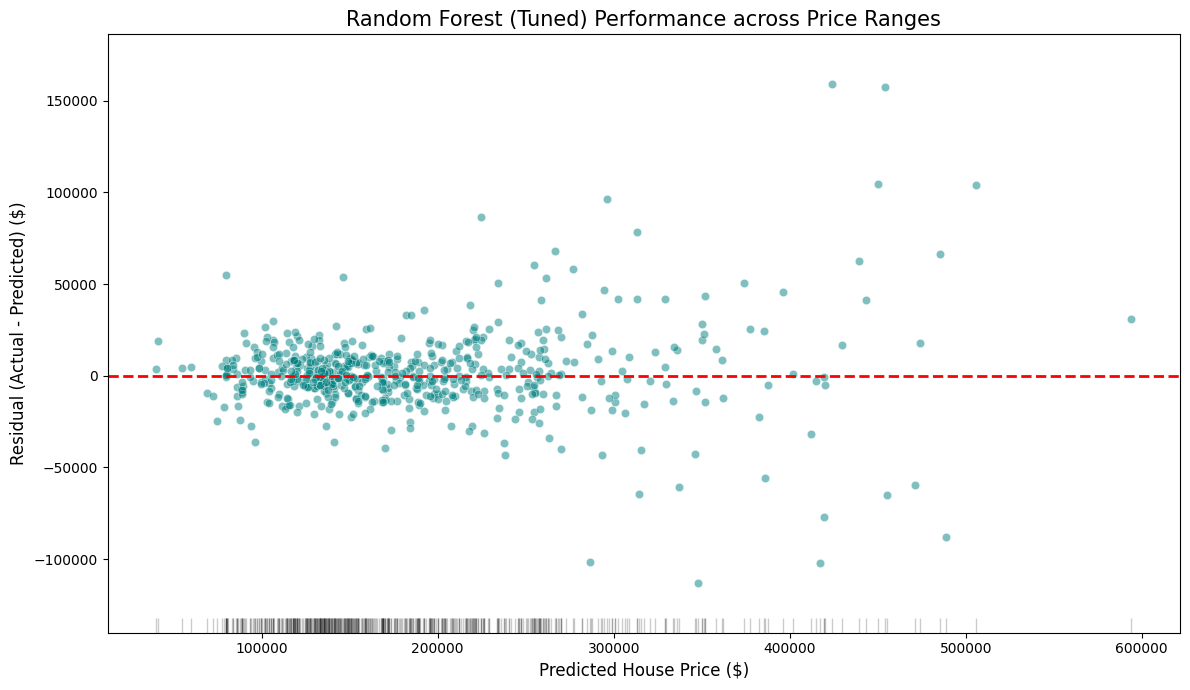

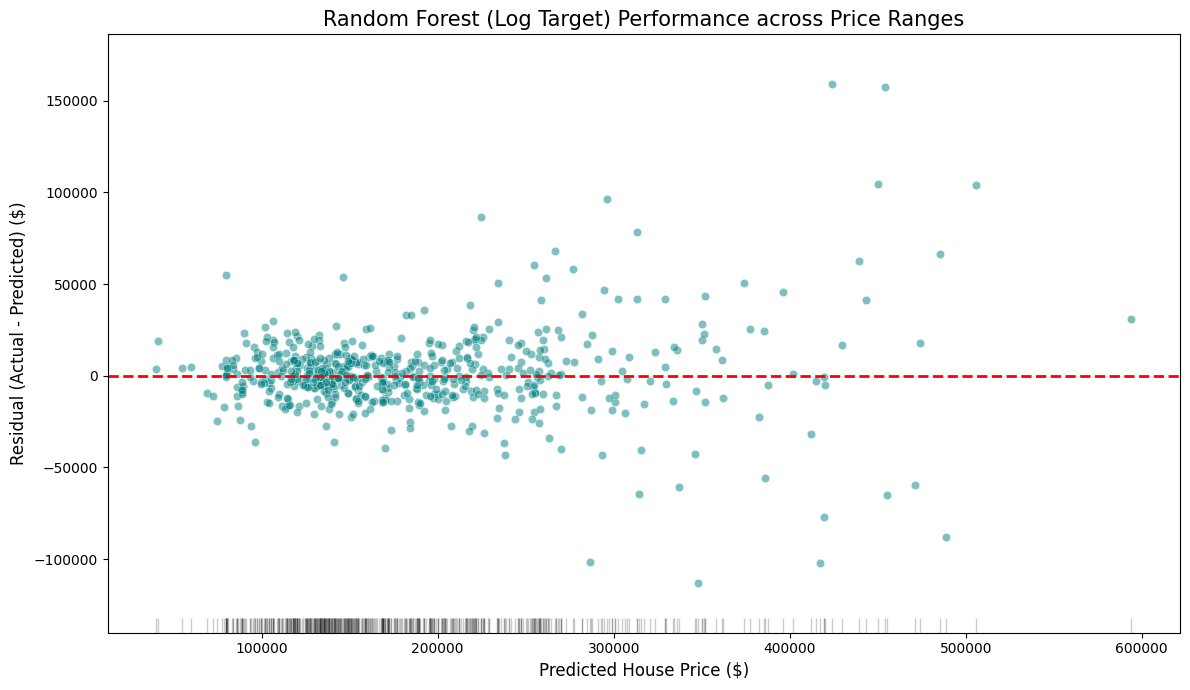

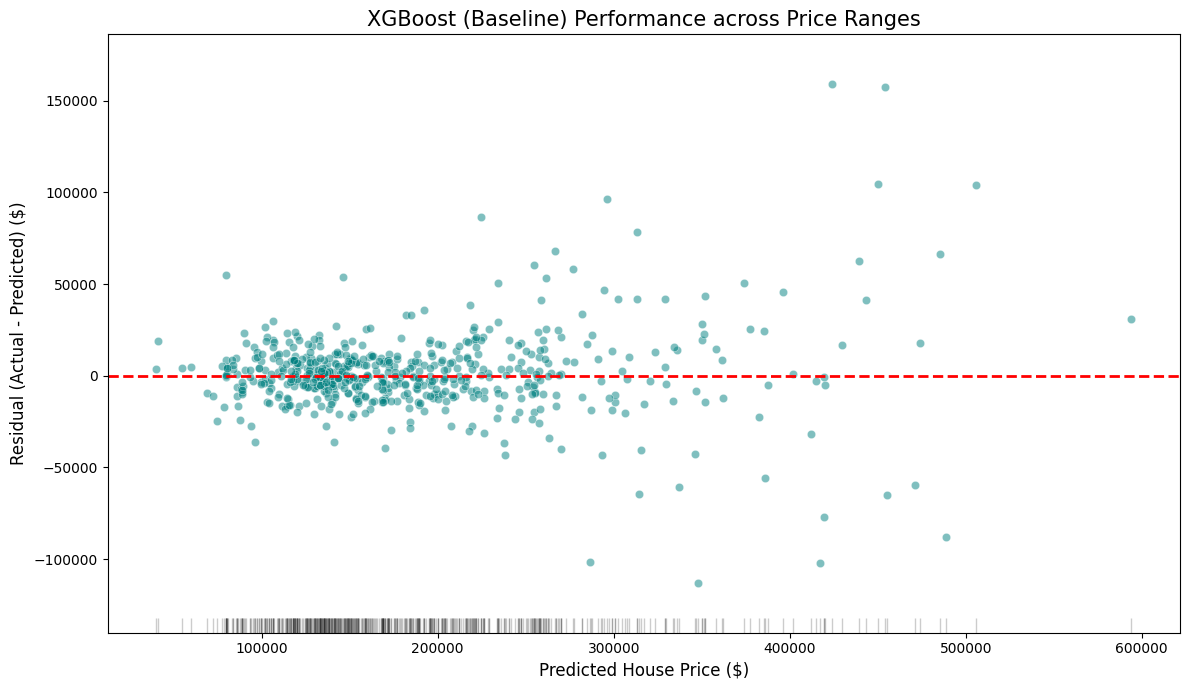

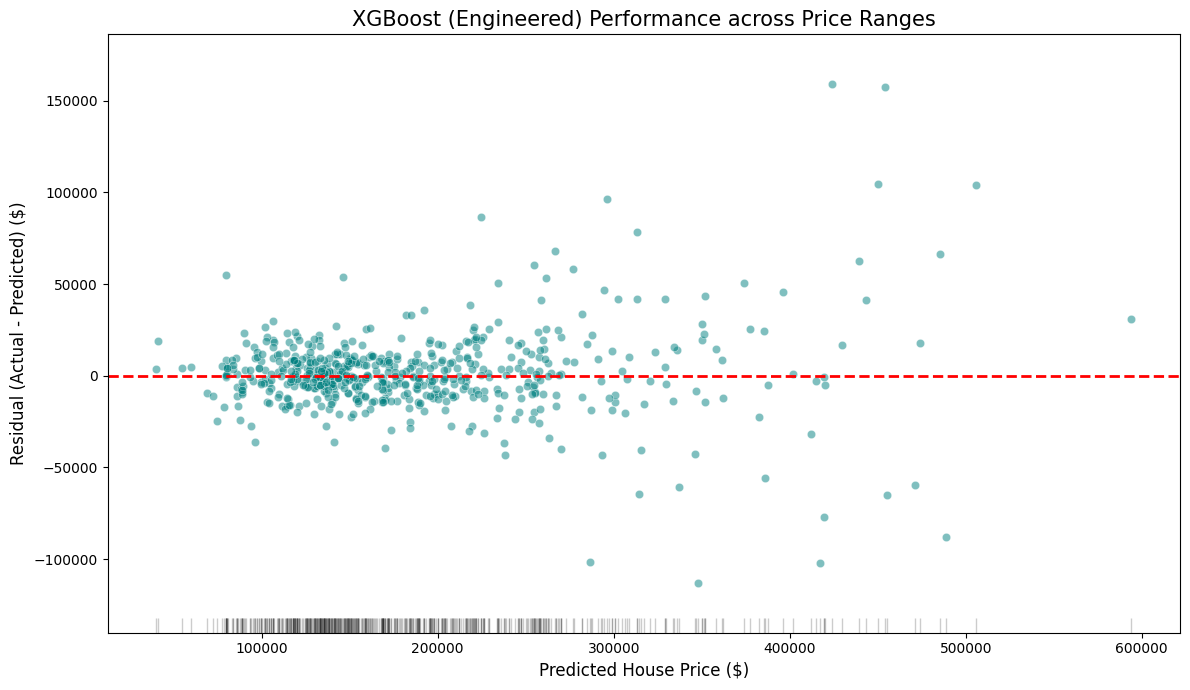

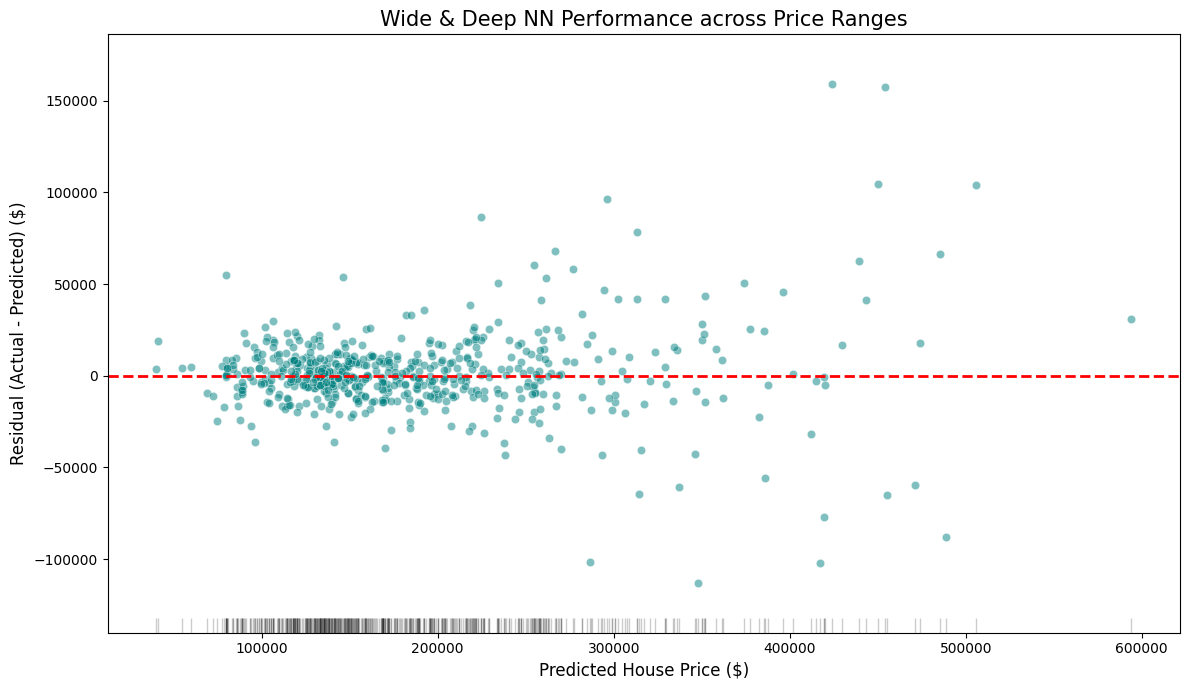

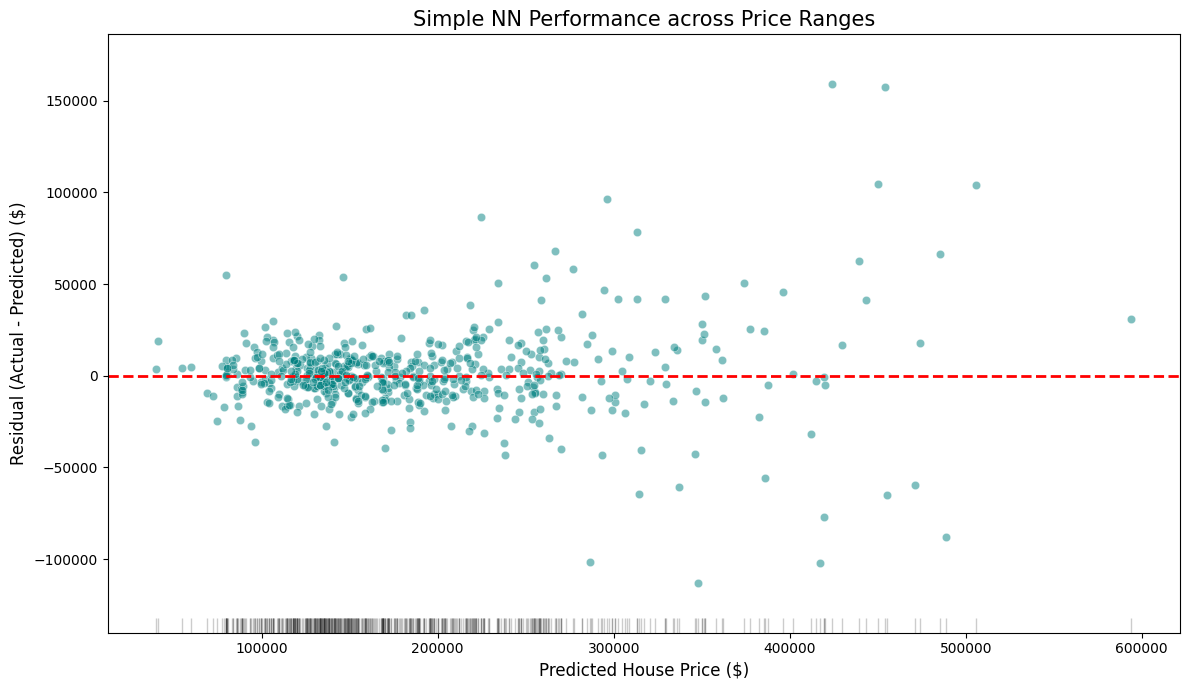

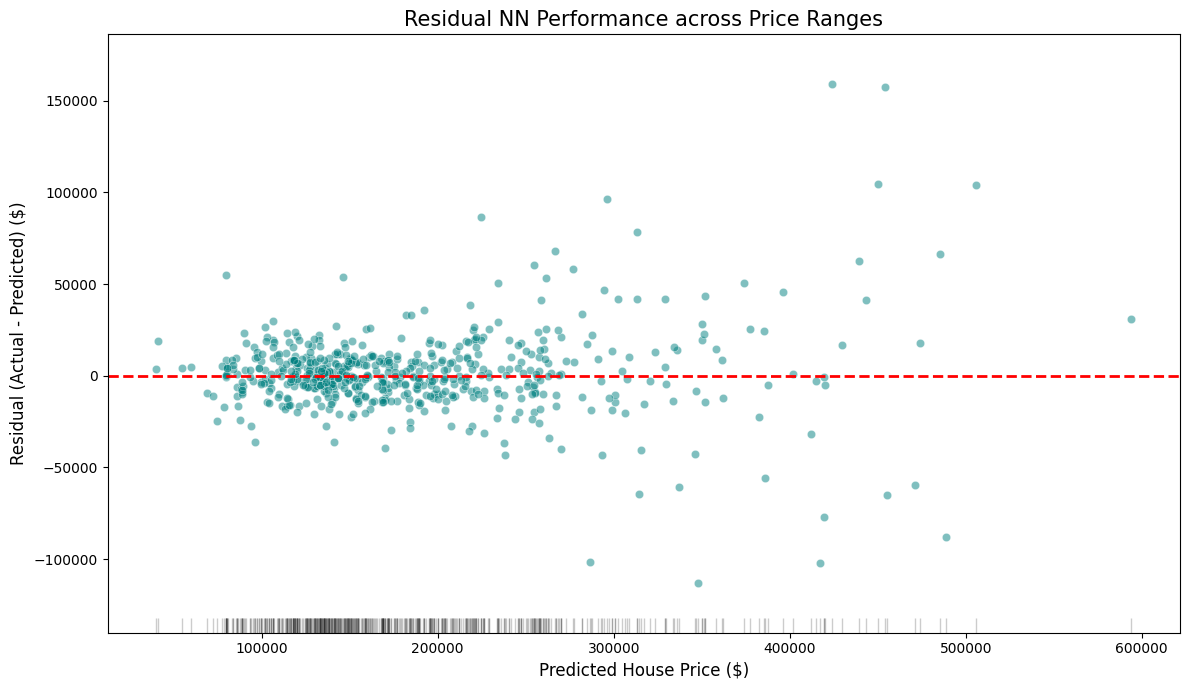

,Model,RMSE,MAE
0,XGBoost (Engineered),"$22,895.88","$13,216.65"
1,XGBoost (Baseline),"$25,471.74","$14,450.59"
2,Random Forest (Log Target),"$25,899.30","$15,003.38"
3,Random Forest (Tuned),"$25,997.49","$15,019.34"
4,Random Forest (Baseline),"$27,002.02","$15,940.36"
5,Residual NN,"$33,113.55","$16,545.93"
6,Simple NN,"$37,287.55","$22,045.48"
7,Wide & Deep NN,"$536,452.25","$37,998.93"


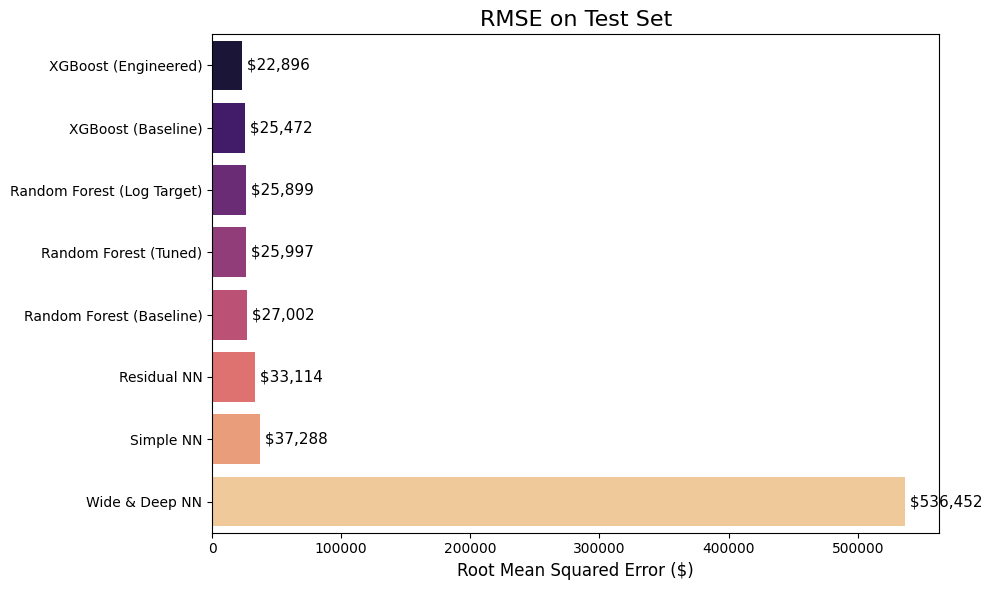

In [249]:
def evaluate_model(name, model, X_test_data, y_test_data, is_nn=False):
    if is_nn:
        preds_log = model.predict(X_test_data, verbose=0).flatten()
        preds = np.expm1(preds_log)
    else:
        preds = model.predict(X_test_data)

    rmse = root_mean_squared_error(y_test_data, preds)
    mae = mean_absolute_error(y_test_data, preds)

    preds = xgb_final.predict(rf_X_val)
    residuals = y_test_data - preds

    plt.figure(figsize=(12, 7))

    sns.scatterplot(x=preds, y=residuals, alpha=0.5, color="teal")

    plt.axhline(y=0, color="red", linestyle="--", linewidth=2)

    plt.title(f"{name} Performance across Price Ranges", fontsize=15)
    plt.xlabel("Predicted House Price ($)", fontsize=12)
    plt.ylabel("Residual (Actual - Predicted) ($)", fontsize=12)

    sns.rugplot(x=preds, color="black", alpha=0.2)

    plt.tight_layout()
    plt.show()

    return {"Model": name, "RMSE": rmse, "MAE": mae}


models_to_test = {
    "Random Forest (Baseline)": rf_simple,
    "Random Forest (Tuned)": rF_tuned,
    "Random Forest (Log Target)": rf_log,
    "XGBoost (Baseline)": xgb_simple,
    "XGBoost (Engineered)": best_xgb,
}

results = []

for name, mdl in models_to_test.items():
    try:
        results.append(evaluate_model(name, mdl, rf_X_val, rf_y_val))
    except Exception as e:
        print(f"Skipping {name} (not found or error): {e}")

try:
    results.append(
        evaluate_model("Wide & Deep NN", model, X_val_nn, rf_y_val, is_nn=True)
    )
except Exception as e:
    print(f"Skipping Neural Network: {e}")

try:
    results.append(
        evaluate_model("Simple NN", simple_nn, X_val_nn, rf_y_val, is_nn=True)
    )
except Exception as e:
    print(f"Skipping Neural Network: {e}")

try:
    results.append(
        evaluate_model("Residual NN", res_nn, X_val_nn, rf_y_val, is_nn=True)
    )
except Exception as e:
    print(f"Skipping Neural Network: {e}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

styled_df = results_df.style.format(
    {"RMSE": "${:,.2f}", "MAE": "${:,.2f}"}
).background_gradient(cmap="Blues", subset=["RMSE", "MAE"])

display(styled_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df, x="RMSE", y="Model", hue="Model", palette="magma", legend=False
)

plt.title("RMSE on Test Set", fontsize=16)
plt.xlabel("Root Mean Squared Error ($)", fontsize=12)
plt.ylabel("")

for index, value in enumerate(results_df["RMSE"]):
    plt.text(value, index, f" ${value:,.0f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()


# Conclusions

- XGBoost turned out to be the best performing model, beating Neural Networks. Tree-based models are generally better suited for tabular data.
- Feature engineering and data cleaning provides better results than hyperparameter tuning
- Log-Transform is crucial for imbalanced distributions with non-constant variance
- One-hot encoding can be replaced with simple number scale encoding for tree models, as is doesn't break them
